In [8]:
#@title Install dependencies (run in Colab; skip if running locally with torch already installed)
try:
    import torch
except Exception:
    %pip install -q torch torchvision tqdm matplotlib
print('Ready')


Ready


In [9]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os, random
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## Model, training & utilities

In [11]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dims=[512,256], num_classes=10, dropout_p=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout_p and dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

def get_data_loaders(batch_size=128, val_split=0.1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    val_len = int(len(dataset) * val_split)
    train_len = len(dataset) - val_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    losses = []
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return np.mean(losses), correct / total

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return np.mean(losses), correct / total

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.wait = 0
        self.should_stop = False
        self.best_state = None
    def step(self, current_loss, model):
        if current_loss + self.min_delta < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
            self.best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.should_stop = True
    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def plot_history(history):
    epochs = len(history['train_loss'])
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), history['train_loss'], label='train loss')
    plt.plot(range(1, epochs+1), history['val_loss'], label='val loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(range(1, epochs+1), history['train_acc'], label='train acc')
    plt.plot(range(1, epochs+1), history['val_acc'], label='val acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout()

def run_experiment(epochs=20, batch_size=128, lr=1e-3, hidden_dims=[512,256], dropout=0.0, weight_decay=0.0, early_stop_patience=None):
    train_loader, val_loader, test_loader = get_data_loaders(batch_size=batch_size)
    model = SimpleMLP(hidden_dims=hidden_dims, dropout_p=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopper = None
    if early_stop_patience is not None and early_stop_patience > 0:
        early_stopper = EarlyStopping(patience=early_stop_patience, min_delta=1e-4)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch:02d} | Train loss: {train_loss:.4f}, acc: {train_acc*100:.2f}% | Val loss: {val_loss:.4f}, acc: {val_acc*100:.2f}%")
        if early_stopper is not None:
            early_stopper.step(val_loss, model)
            if early_stopper.should_stop:
                print(f"Early stopping at epoch {epoch}. Restoring best model (val_loss={early_stopper.best_loss:.4f})")
                early_stopper.restore_best(model)
                break
    test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
    print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc*100:.2f}%")
    return model, history, (test_loss, test_acc)


## Run baseline experiment (no regularization)
Run the cell below (this will download MNIST and train the MLP). In Colab, enable GPU runtime for much faster training.

Epoch 01 | Train loss: 0.2382, acc: 92.91% | Val loss: 0.1234, acc: 96.20%
Epoch 02 | Train loss: 0.0905, acc: 97.23% | Val loss: 0.1193, acc: 96.52%
Epoch 03 | Train loss: 0.0625, acc: 98.01% | Val loss: 0.1072, acc: 96.67%
Epoch 04 | Train loss: 0.0451, acc: 98.53% | Val loss: 0.0857, acc: 97.48%
Epoch 05 | Train loss: 0.0344, acc: 98.86% | Val loss: 0.0920, acc: 97.52%
Epoch 06 | Train loss: 0.0271, acc: 99.09% | Val loss: 0.0800, acc: 97.92%
Epoch 07 | Train loss: 0.0233, acc: 99.21% | Val loss: 0.1011, acc: 97.55%
Epoch 08 | Train loss: 0.0224, acc: 99.27% | Val loss: 0.0907, acc: 97.67%
Epoch 09 | Train loss: 0.0214, acc: 99.28% | Val loss: 0.1115, acc: 97.23%
Epoch 10 | Train loss: 0.0138, acc: 99.55% | Val loss: 0.1075, acc: 97.70%
Test loss: 0.0892, Test acc: 98.04%


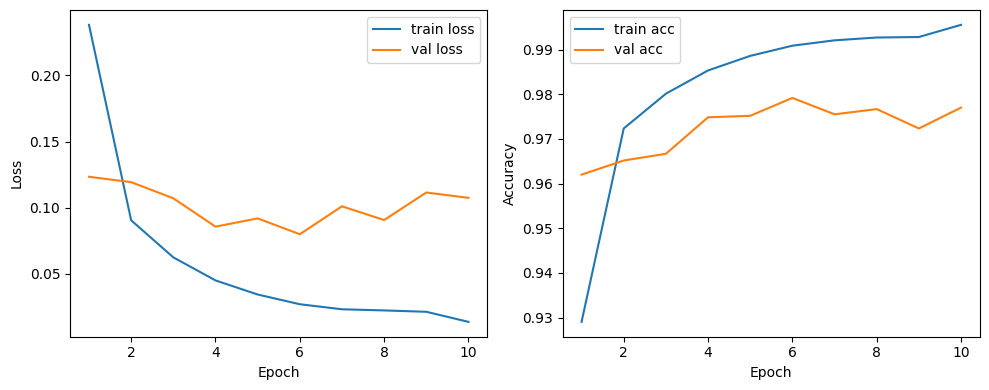

In [12]:
#@title Baseline: no weight decay, no dropout
model, history, test_stats = run_experiment(epochs=10, batch_size=128, lr=1e-3, dropout=0.0, weight_decay=0.0)
plot_history(history)


## Experiments: L2 (weight decay), Dropout, Early Stopping
Run the following cells to compare several configurations. You can modify hyperparameters to explore more.


=== Running baseline ===
Epoch 01 | Train loss: 0.2418, acc: 92.81% | Val loss: 0.1393, acc: 95.72%
Epoch 02 | Train loss: 0.0909, acc: 97.17% | Val loss: 0.0956, acc: 97.13%
Epoch 03 | Train loss: 0.0623, acc: 98.06% | Val loss: 0.0945, acc: 97.17%
Epoch 04 | Train loss: 0.0435, acc: 98.61% | Val loss: 0.0939, acc: 97.33%
Epoch 05 | Train loss: 0.0336, acc: 98.93% | Val loss: 0.0961, acc: 97.28%
Epoch 06 | Train loss: 0.0277, acc: 99.06% | Val loss: 0.0944, acc: 97.42%
Epoch 07 | Train loss: 0.0244, acc: 99.21% | Val loss: 0.0934, acc: 97.73%
Epoch 08 | Train loss: 0.0221, acc: 99.29% | Val loss: 0.0896, acc: 97.60%
Epoch 09 | Train loss: 0.0167, acc: 99.47% | Val loss: 0.1025, acc: 97.47%
Epoch 10 | Train loss: 0.0190, acc: 99.36% | Val loss: 0.1104, acc: 97.45%
Epoch 11 | Train loss: 0.0174, acc: 99.44% | Val loss: 0.0956, acc: 97.75%
Epoch 12 | Train loss: 0.0103, acc: 99.68% | Val loss: 0.0954, acc: 98.13%
Epoch 13 | Train loss: 0.0138, acc: 99.53% | Val loss: 0.1338, acc: 97.48%

KeyboardInterrupt: 

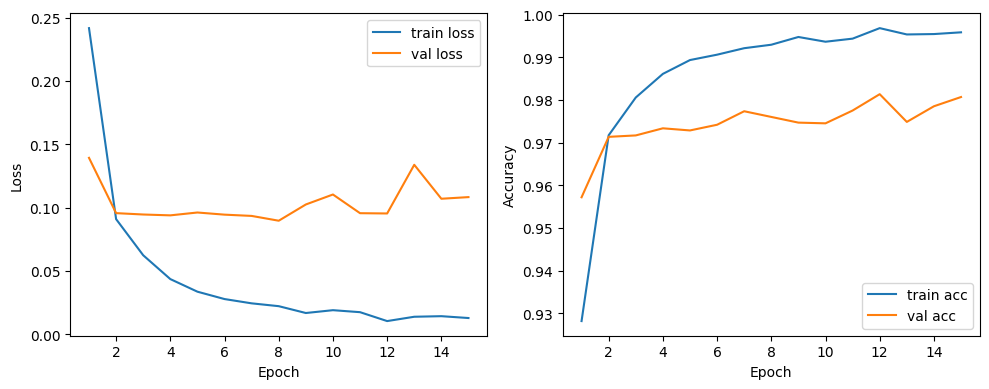

In [ ]:
#@title Experiment runner (multiple configs)
configs = [
    {'name':'baseline','dropout':0.0,'weight_decay':0.0,'early':None},
    {'name':'l2_1e-4','dropout':0.0,'weight_decay':1e-4,'early':None},
    {'name':'dropout_0.5','dropout':0.5,'weight_decay':0.0,'early':None},
    {'name':'l2+dropout+early','dropout':0.3,'weight_decay':1e-4,'early':5},
]
results = {}
for cfg in configs:
    print('\n=== Running', cfg['name'], '===')
    model, history, test_stats = run_experiment(epochs=15, batch_size=128, lr=1e-3, dropout=cfg['dropout'], weight_decay=cfg['weight_decay'], early_stop_patience=cfg['early'])
    results[cfg['name']] = {'history':history, 'test':test_stats}
print('\nAll experiments done')


## Lab Questions (to submit)
1. Run baseline and record validation & test accuracy (attach training plots). [1]
2. Try weight decay values `1e-5, 1e-4, 1e-3`. Which is best? Attach numbers and plots.  [2]
3. Try dropout `0.2, 0.5`. Report results and show curves.  [1]
4. Enable early stopping (`patience=5`). Record the epoch it triggered (or mention if it didn't) and the final test accuracy.  [1]
5. Final table (method, val acc, test acc, remarks) comparing Baseline / L2 / Dropout / L2+Dropout+EarlyStopping.  [3]
6. Short answers: explain how L2 affects weights/loss; how dropout affects training; when to use early stopping.  [2]

Marks: 10 (same rubric as instructor file).

------------------------------------------------------------------------------------------------
### Question 1

Epoch 01 | Train loss: 0.2428, acc: 92.80% | Val loss: 0.1370, acc: 95.85%
Epoch 02 | Train loss: 0.0901, acc: 97.26% | Val loss: 0.0931, acc: 97.25%
Epoch 03 | Train loss: 0.0606, acc: 98.07% | Val loss: 0.0911, acc: 97.23%
Epoch 04 | Train loss: 0.0444, acc: 98.57% | Val loss: 0.0947, acc: 97.48%
Epoch 05 | Train loss: 0.0340, acc: 98.90% | Val loss: 0.0781, acc: 97.65%
Test loss: 0.0731, Test acc: 97.81%


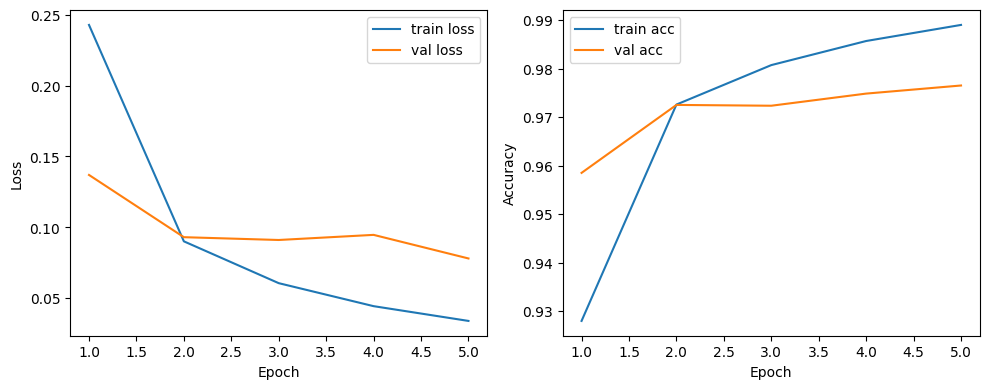

In [ ]:
config_q1=next(cfg for cfg in configs if cfg['name']=='baseline')
model, history, test_stats=run_experiment(
    epochs=5,
    dropout=config_q1['dropout'],
    weight_decay=config_q1['weight_decay'],
    early_stop_patience=config_q1['early']
)
plot_history(history)

Test loss: 0.0731, Test acc: 97.81%

------------------------------------------------------------------------------------------------
### Question 2

Epoch 01 | Train loss: 0.2409, acc: 92.80% | Val loss: 0.1277, acc: 96.10%
Epoch 02 | Train loss: 0.0914, acc: 97.15% | Val loss: 0.1002, acc: 96.95%
Epoch 03 | Train loss: 0.0617, acc: 98.05% | Val loss: 0.0890, acc: 97.13%
Epoch 04 | Train loss: 0.0462, acc: 98.46% | Val loss: 0.0888, acc: 97.48%
Epoch 05 | Train loss: 0.0375, acc: 98.74% | Val loss: 0.0976, acc: 97.40%
Test loss: 0.0910, Test acc: 97.44%


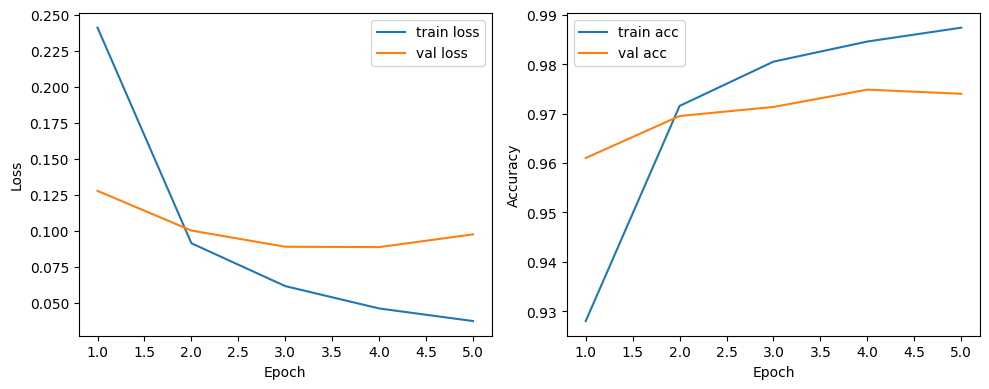

In [20]:
model, his, test_stats=run_experiment(
    epochs=5, weight_decay=1e-5
)
plot_history(his)

Epoch 01 | Train loss: 0.2391, acc: 92.81% | Val loss: 0.1374, acc: 95.73%
Epoch 02 | Train loss: 0.0925, acc: 97.19% | Val loss: 0.0957, acc: 97.13%
Epoch 03 | Train loss: 0.0621, acc: 97.98% | Val loss: 0.0922, acc: 97.08%
Epoch 04 | Train loss: 0.0470, acc: 98.49% | Val loss: 0.0899, acc: 97.35%
Epoch 05 | Train loss: 0.0376, acc: 98.81% | Val loss: 0.0774, acc: 97.72%
Test loss: 0.0605, Test acc: 98.05%


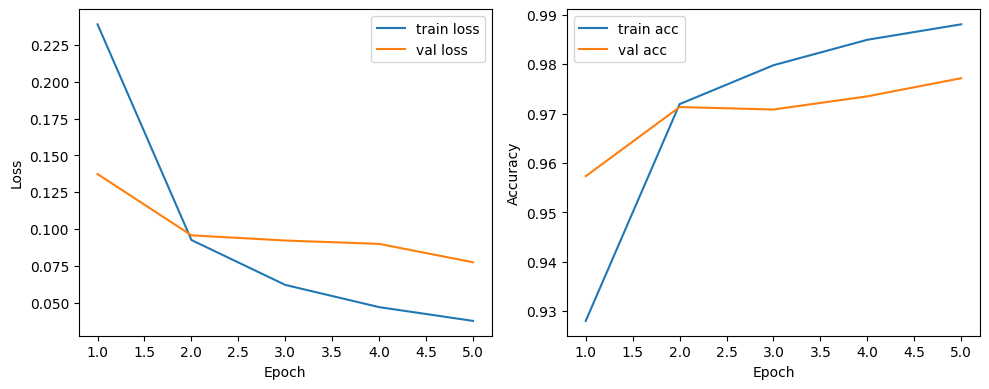

In [21]:
model, his, test_stats=run_experiment(
    epochs=5, weight_decay=1e-4
)
plot_history(his)

Epoch 01 | Train loss: 0.2450, acc: 92.69% | Val loss: 0.1299, acc: 96.03%
Epoch 02 | Train loss: 0.1049, acc: 96.76% | Val loss: 0.1001, acc: 96.85%
Epoch 03 | Train loss: 0.0842, acc: 97.42% | Val loss: 0.1129, acc: 96.25%
Epoch 04 | Train loss: 0.0739, acc: 97.72% | Val loss: 0.0981, acc: 96.87%
Epoch 05 | Train loss: 0.0658, acc: 97.93% | Val loss: 0.0856, acc: 97.32%
Test loss: 0.0681, Test acc: 97.83%


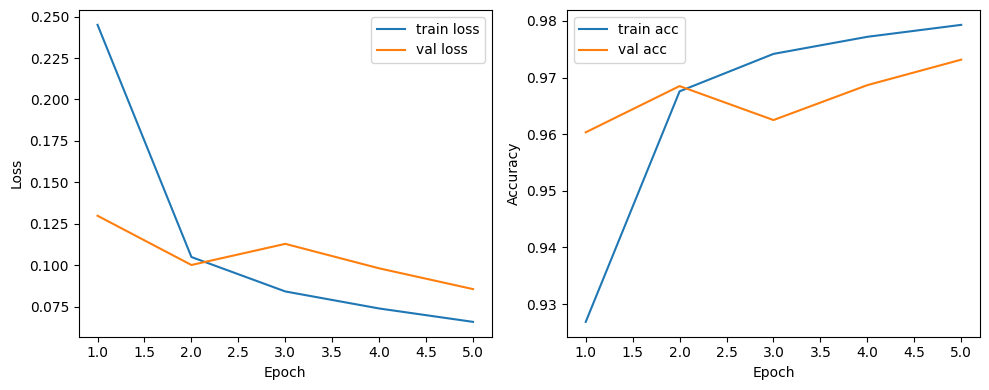

In [22]:
model, his, test_stats=run_experiment(
    epochs=5, weight_decay=1e-3
)
plot_history(his)

for weight decay 1e-5, Test loss: 0.0910, Test acc: 97.44%

for weight decay 1e-4, Test loss: 0.0605, Test acc: 98.05%

for weight decay 1e-3, Test loss: 0.0681, Test acc: 97.83%

Weight decay=1e-4 seems to offer best outputs

------------------------------------------------------------------------------------------------
### Question 3

Epoch 01 | Train loss: 0.2669, acc: 91.89% | Val loss: 0.1256, acc: 96.38%
Epoch 02 | Train loss: 0.1124, acc: 96.55% | Val loss: 0.0991, acc: 96.97%
Epoch 03 | Train loss: 0.0855, acc: 97.26% | Val loss: 0.0900, acc: 97.25%
Epoch 04 | Train loss: 0.0683, acc: 97.78% | Val loss: 0.0942, acc: 97.43%
Epoch 05 | Train loss: 0.0562, acc: 98.22% | Val loss: 0.0919, acc: 97.57%
Test loss: 0.0739, Test acc: 97.74%


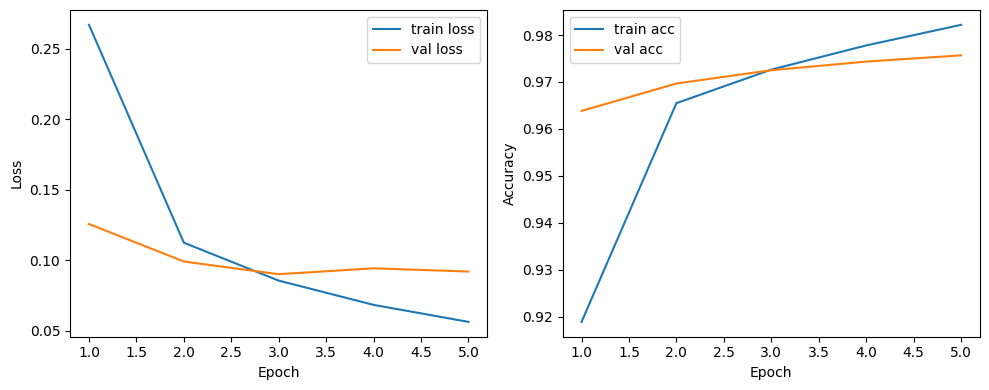

In [23]:
model, hist, test_stats=run_experiment(
    epochs=5, dropout=0.2
)
plot_history(hist)

Epoch 01 | Train loss: 0.3611, acc: 88.89% | Val loss: 0.1542, acc: 95.20%
Epoch 02 | Train loss: 0.1817, acc: 94.49% | Val loss: 0.1210, acc: 96.55%
Epoch 03 | Train loss: 0.1465, acc: 95.65% | Val loss: 0.0998, acc: 97.23%
Epoch 04 | Train loss: 0.1251, acc: 96.25% | Val loss: 0.0926, acc: 97.38%
Epoch 05 | Train loss: 0.1170, acc: 96.40% | Val loss: 0.0874, acc: 97.47%
Test loss: 0.0790, Test acc: 97.63%


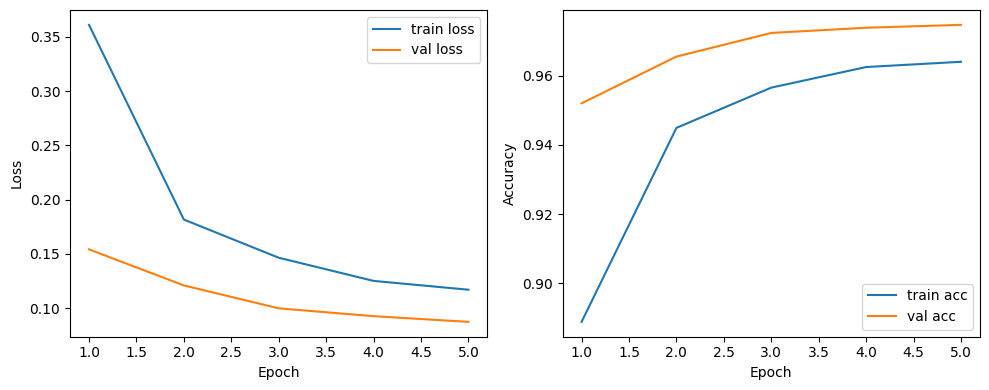

In [24]:
model, hist, test_stats=run_experiment(
    epochs=5, dropout=0.5
)
plot_history(hist)

dropout=0.2 --> Test loss: 0.0739, Test acc: 97.74%

dropout=0.5 --> Test loss: 0.0790, Test acc: 97.63%

------------------------------------------------------------------------------------------------
### Question 4

In [27]:
model, hist, test_stats=run_experiment(
    epochs=10,
    early_stop_patience=3
)

Epoch 01 | Train loss: 0.2360, acc: 92.89% | Val loss: 0.1234, acc: 96.37%
Epoch 02 | Train loss: 0.0923, acc: 97.14% | Val loss: 0.0901, acc: 97.12%
Epoch 03 | Train loss: 0.0607, acc: 98.09% | Val loss: 0.0921, acc: 97.20%
Epoch 04 | Train loss: 0.0458, acc: 98.57% | Val loss: 0.1005, acc: 96.88%
Epoch 05 | Train loss: 0.0334, acc: 98.96% | Val loss: 0.0904, acc: 97.28%
Early stopping at epoch 5. Restoring best model (val_loss=0.0901)
Test loss: 0.0714, Test acc: 97.62%


Reduced epochs to 10, and patience to 3, to make testing more feasible.

Recorded early stopping at epoch 5.

Upon further investigation, validation loss consistently increased from epoch 2-5.

final test accuracy was the same as accuracy for epoch 2, 97.12%.

------------------------------------------------------------------------------------------------
### Question 5

In [28]:
#@title Experiment runner (multiple configs)
configs = [
    {'name':'baseline','dropout':0.0,'weight_decay':0.0,'early':None},
    {'name':'l2_1e-4','dropout':0.0,'weight_decay':1e-4,'early':None},
    {'name':'dropout_0.5','dropout':0.5,'weight_decay':0.0,'early':None},
    {'name':'l2+dropout+early','dropout':0.3,'weight_decay':1e-4,'early':5},
]
results = {}
for cfg in configs:
    print('\n=== Running', cfg['name'], '===')
    model, history, test_stats = run_experiment(epochs=5, batch_size=128, lr=1e-3, dropout=cfg['dropout'], weight_decay=cfg['weight_decay'], early_stop_patience=cfg['early'])
    results[cfg['name']] = {'history':history, 'test':test_stats}
print('\nAll experiments done')


=== Running baseline ===
Epoch 01 | Train loss: 0.2401, acc: 92.84% | Val loss: 0.1209, acc: 96.42%
Epoch 02 | Train loss: 0.0903, acc: 97.20% | Val loss: 0.0945, acc: 97.08%
Epoch 03 | Train loss: 0.0610, acc: 98.11% | Val loss: 0.1087, acc: 96.75%
Epoch 04 | Train loss: 0.0457, acc: 98.54% | Val loss: 0.0858, acc: 97.53%
Epoch 05 | Train loss: 0.0343, acc: 98.92% | Val loss: 0.0779, acc: 97.77%
Test loss: 0.0670, Test acc: 98.00%

=== Running l2_1e-4 ===
Epoch 01 | Train loss: 0.2417, acc: 92.77% | Val loss: 0.1539, acc: 95.17%
Epoch 02 | Train loss: 0.0923, acc: 97.14% | Val loss: 0.0992, acc: 96.87%
Epoch 03 | Train loss: 0.0633, acc: 98.01% | Val loss: 0.0838, acc: 97.48%
Epoch 04 | Train loss: 0.0489, acc: 98.43% | Val loss: 0.0755, acc: 97.50%
Epoch 05 | Train loss: 0.0385, acc: 98.75% | Val loss: 0.0834, acc: 97.62%
Test loss: 0.0772, Test acc: 97.83%

=== Running dropout_0.5 ===
Epoch 01 | Train loss: 0.3655, acc: 88.77% | Val loss: 0.1584, acc: 95.05%
Epoch 02 | Train loss: 

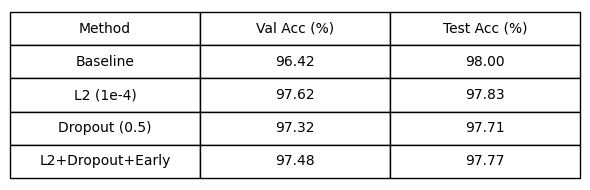

In [ ]:
import matplotlib.pyplot as plt

methods=['Baseline', 'L2 (1e-4)', 'Dropout (0.5)', 'L2+Dropout+Early']
val_acc=[96.42, 97.62, 97.32, 97.48]
test_acc=[98.00, 97.83, 97.71, 97.77]

fig, ax=plt.subplots(figsize=(6, 2))
ax.axis('off')

table_data=[
    ["Method", 
    "Val Acc (%)",
    "Test Acc (%)"
    ]
]
for m, v, t in zip(methods, val_acc, test_acc):
    table_data.append([m, f"{v:.2f}", f"{t:.2f}"])

table = ax.table(cellText=table_data, loc='center', cellLoc='center', colLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

plt.tight_layout()
plt.show()


------------------------------------------------------------------------------------------------
### Question 6

#### Answer:

q1) L2 regularisation adds penalty proportional to the square of loss, discouraging very large weights, and instead shrinks towards 0, reducing model complexity.

q2) dropout randomly drops one of the parameters setting it to 0, this forces bias generation and redundancy, improving generalization.


q3) used for when validation loss stops dropping alongside training loss, or even starts increasing, indicating overfitting.


------------------------------------------------------------------------------------------------